# BioSentinel India: Spatial-Temporal Intelligence

**Owner:** Person 2  
**Scope:** Temporal trends, spatial coverage, sampling-effort concentration, grid-level coverage flags, and historical baseline construction.

This notebook consumes the validated Grid × Year indicators generated by `02_biodiversity_data_analysis.ipynb`.

**Important interpretation:** GBIF `occurrences` are observation records, not animal abundance. Spatial and temporal patterns therefore describe observation-derived biodiversity evidence and must be interpreted together with sampling coverage.

## 1. Setup and shared analysis parameters

The primary comparison period is **2015–2024**, matching the biodiversity-indicator notebook. Years 2025–2026 are retained in the source audit but excluded from the comparable analysis because their coverage is incomplete.

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the BioSentinel project root containing data/ and notebooks/."
    )

PROJECT_ROOT = find_project_root()

ANALYTICS_DIR = PROJECT_ROOT / "data" / "processed" / "analytics"
INPUT_PATH = ANALYTICS_DIR / "grid_year_biodiversity_indicators.parquet"
ANNUAL_PATH = ANALYTICS_DIR / "annual_species_richness.csv"
OUTPUT_DIR = ANALYTICS_DIR

ANALYSIS_START_YEAR = 2015
ANALYSIS_END_YEAR = 2024
MIN_OCCURRENCES = 25
MIN_SPECIES = 2
MIN_BASELINE_YEARS = 3

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Required Person 1 output not found: {INPUT_PATH}\n"
        "Run notebooks/02_biodiversity_data_analysis.ipynb first."
    )

print("Project root:", PROJECT_ROOT)
print("Input:", INPUT_PATH)
print(f"Primary analysis period: {ANALYSIS_START_YEAR}-{ANALYSIS_END_YEAR}")
print(f"Sampling threshold: >= {MIN_OCCURRENCES} GBIF records and >= {MIN_SPECIES} species")


Project root: d:\Biosential_India
Input: d:\Biosential_India\data\processed\analytics\grid_year_biodiversity_indicators.parquet
Primary analysis period: 2015-2024
Sampling threshold: >= 25 GBIF records and >= 2 species


## 2. Load and validate the Grid × Year indicators

No synthetic fallback data are used. Missing upstream outputs should stop the pipeline rather than silently producing placeholder results.

In [26]:
required_columns = [
    "eqdcellcode",
    "year",
    "total_occurrences",
    "species_richness",
    "shannon_diversity",
    "simpson_diversity",
    "pielou_evenness",
]

data = pd.read_parquet(INPUT_PATH, columns=required_columns)

data["year"] = pd.to_numeric(data["year"], errors="raise").astype(int)
data["total_occurrences"] = pd.to_numeric(
    data["total_occurrences"], errors="raise"
).astype("int64")
data["species_richness"] = pd.to_numeric(
    data["species_richness"], errors="raise"
).astype("int64")

data = data[
    data["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    & data["total_occurrences"].gt(0)
].copy()

if data["eqdcellcode"].isna().any():
    raise ValueError("Missing eqdcellcode detected in analytical data.")

if data.duplicated(["eqdcellcode", "year"]).any():
    raise ValueError("Duplicate Grid × Year groups detected.")

data["sampling_adequate"] = (
    data["total_occurrences"].ge(MIN_OCCURRENCES)
    & data["species_richness"].ge(MIN_SPECIES)
)

data["sampling_flag"] = np.where(
    data["sampling_adequate"],
    "usable_with_caution",
    "data_limited",
)

print(f"Grid × Year rows: {len(data):,}")
print(f"Occupied grid cells: {data['eqdcellcode'].nunique():,}")
print(f"Years: {data['year'].min()}–{data['year'].max()}")
print(f"Underlying GBIF records: {data['total_occurrences'].sum():,}")
print(
    f"Sampling-adequate Grid × Year units: "
    f"{data['sampling_adequate'].sum():,} "
    f"({data['sampling_adequate'].mean() * 100:.1f}%)"
)
data.head()


Grid × Year rows: 36,078
Occupied grid cells: 6,625
Years: 2015–2024
Underlying GBIF records: 59,081,332
Sampling-adequate Grid × Year units: 23,821 (66.0%)


,eqdcellcode,year,total_occurrences,species_richness,shannon_diversity,simpson_diversity,pielou_evenness,sampling_adequate,sampling_flag
0,E083N19DB,2023,13,13,2.564949,0.923077,1.000000,False,data_limited
1,E083N19DB,2024,184,119,4.541900,0.985232,0.950363,True,usable_with_caution
2,E085N20DA,2015,104,82,4.341074,0.985947,0.985103,True,usable_with_caution
3,E085N20DA,2016,248,102,4.470812,0.986993,0.966668,True,usable_with_caution
4,E085N20DA,2017,1875,174,4.630273,0.986844,0.897504,True,usable_with_caution


## 3. Temporal trends and observation effort

In [27]:
annual = (
    data.groupby("year", as_index=False)
    .agg(
        total_occurrences=("total_occurrences", "sum"),
        species_richness=("species_richness", "sum"),
        occupied_grids=("eqdcellcode", "nunique"),
        sampling_adequate_grid_years=("sampling_adequate", "sum"),
    )
)

# National richness should be distinct species, so use Person 1's annual table if available.
if ANNUAL_PATH.exists():
    annual_source = pd.read_csv(ANNUAL_PATH)
    annual_source = annual_source[
        annual_source["year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ][["year", "species_richness", "total_occurrences", "occupied_grids"]].copy()
    annual = annual_source.merge(
        annual[["year", "sampling_adequate_grid_years"]],
        on="year",
        how="left",
        validate="one_to_one",
    )

annual


,year,species_richness,total_occurrences,occupied_grids,sampling_adequate_grid_years
0,2015,3195,1585689,2465,1462
1,2016,3530,2505748,2683,1656
2,2017,3697,3385533,3100,1931
3,2018,4198,3934813,3304,2119
4,2019,4825,4538386,3687,2366
5,2020,5139,5717323,3515,2341
6,2021,5789,7180201,3843,2640
7,2022,6488,8396584,4290,2921
8,2023,6840,10025093,4716,3125
9,2024,6969,11811962,4475,3260


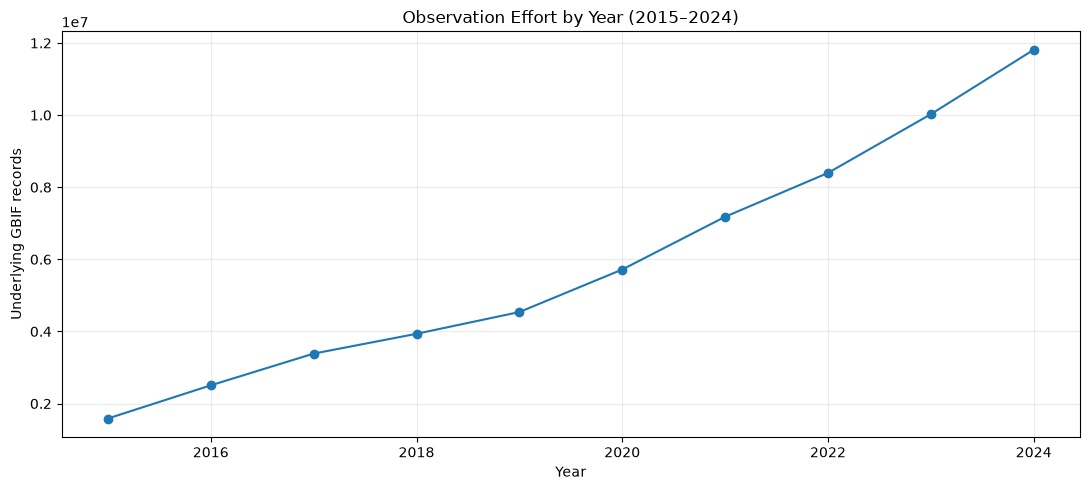

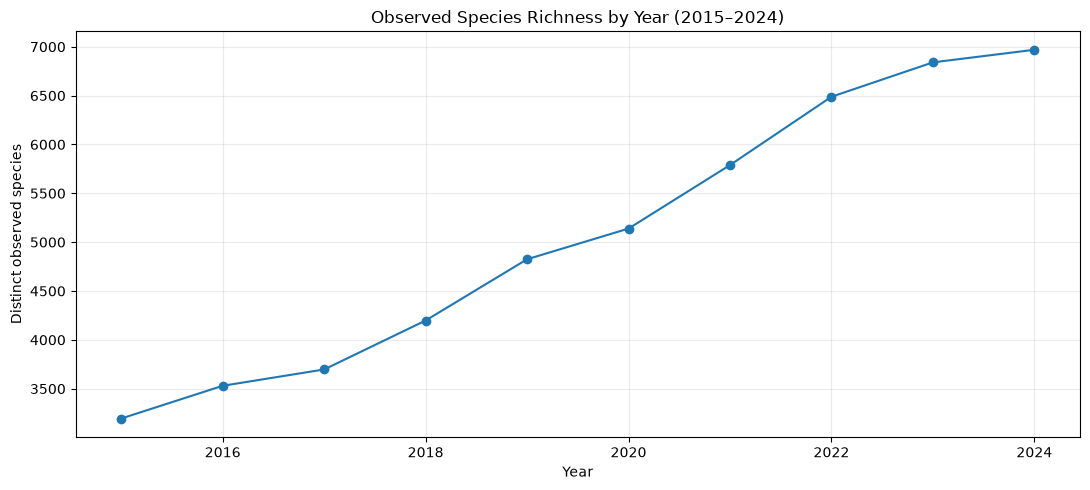

In [28]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    annual["year"],
    annual["total_occurrences"],
    marker="o",
    label="GBIF observation records",
)
ax.set_title("Observation Effort by Year (2015–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Underlying GBIF records")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    annual["year"],
    annual["species_richness"],
    marker="o",
    label="Observed species richness",
)
ax.set_title("Observed Species Richness by Year (2015–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Distinct observed species")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 4. Spatial observation effort

Spatial sampling concentration is measured using **total GBIF observation records per grid cell**, not species richness.

This distinction is essential: a high richness value may partly result from higher observation effort.

In [29]:
spatial = (
    data.groupby("eqdcellcode", as_index=False)
    .agg(
        total_occurrences=("total_occurrences", "sum"),
        observed_species=("species_richness", "sum"),
        observed_years=("year", "nunique"),
        usable_years=("sampling_adequate", "sum"),
    )
)

# observed_species above is a sum of yearly richness and is intentionally named
# differently from distinct species across the full period.
# Recompute the multi-year distinct-species count from the source when available.
# Grid richness from Person 1 is the preferred multi-year distinct-species measure.
grid_richness_path = ANALYTICS_DIR / "grid_species_richness.csv"
if grid_richness_path.exists():
    grid_richness = pd.read_csv(grid_richness_path)
    spatial = spatial.drop(columns=["observed_species"]).merge(
        grid_richness[["eqdcellcode", "species_richness"]].rename(
            columns={"species_richness": "distinct_species_2015_2024"}
        ),
        on="eqdcellcode",
        how="left",
        validate="one_to_one",
    )
else:
    spatial = spatial.rename(columns={"observed_species": "sum_annual_species_richness"})

spatial = spatial.sort_values("total_occurrences", ascending=False).reset_index(drop=True)

spatial.head(20)


,eqdcellcode,total_occurrences,observed_years,usable_years,distinct_species_2015_2024
0,E077N12BA,2136924,10,10,1581
1,E077N13DC,1443286,10,10,1309
2,E072N19DD,733769,10,10,1501
3,E073N18BD,722526,10,10,1166
4,E076N12DA,718899,10,10,960
5,E076N09AB,691315,10,10,1065
6,E080N12AA,666660,10,10,1229
7,E080N22DC,602809,10,10,649
8,E076N11DD,592013,10,10,779
9,E088N22AD,523660,10,10,877


In [30]:
def gini(values):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0 or np.all(x == 0):
        return 0.0
    if np.any(x < 0):
        raise ValueError("Gini input must be non-negative.")
    x = np.sort(x)
    n = len(x)
    return float(np.sum((2 * np.arange(1, n + 1) - n - 1) * x) / (n * x.sum()))

def top_share(values, top_fraction=0.10):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0 or x.sum() == 0:
        return 0.0
    k = max(1, int(np.ceil(len(x) * top_fraction)))
    x = np.sort(x)
    return float(x[-k:].sum() / x.sum())

spatial_gini = gini(spatial["total_occurrences"])
spatial_top10_share = top_share(spatial["total_occurrences"], 0.10)

temporal_gini = gini(annual["total_occurrences"])
temporal_top10_share = top_share(annual["total_occurrences"], 0.10)

print(f"Spatial observation-effort Gini: {spatial_gini:.4f}")
print(f"Top 10% of occupied grid cells share of records: {spatial_top10_share * 100:.2f}%")
print(f"Temporal observation-effort Gini (2015–2024): {temporal_gini:.4f}")
print(f"Top 1 year share of records: {annual['total_occurrences'].max() / annual['total_occurrences'].sum() * 100:.2f}%")


Spatial observation-effort Gini: 0.9213
Top 10% of occupied grid cells share of records: 89.17%
Temporal observation-effort Gini (2015–2024): 0.3058
Top 1 year share of records: 19.99%


## 5. Spatial representation

GBIF's Extended Quarter-Degree Grid Cell (EQDGC) at level 2 represents a 1° cell subdivided into sixteen 15′ × 15′ cells. The parser below derives approximate cell centers for visualization only; it does not recreate the original occurrence coordinates.

Source: GBIF Technical Documentation, `GBIF_EQDGCode`.

In [31]:
def decode_qdgc_center(code):
    """
    Decode a level-2 GBIF EQDGC code to an approximate cell center.

    The two suffix letters recursively select NW/NE/SW/SE quarters:
    A=NW, B=NE, C=SW, D=SE.

    The result is intended for visualization, not for reconstructing
    the original occurrence coordinates.
    """
    import re

    m = re.fullmatch(r"([EW])(\d{3})([NS])(\d{2})([A-D]{2})", str(code))
    if not m:
        return np.nan, np.nan

    ew, lon_deg, ns, lat_deg, suffix = m.groups()
    lon_deg = float(lon_deg)
    lat_deg = float(lat_deg)

    lon_min, lon_max = (lon_deg - 1, lon_deg) if ew == "W" else (lon_deg, lon_deg + 1)
    lat_min, lat_max = (lat_deg - 1, lat_deg) if ns == "S" else (lat_deg, lat_deg + 1)

    for letter in suffix:
        lon_mid = (lon_min + lon_max) / 2
        lat_mid = (lat_min + lat_max) / 2

        if letter == "A":      # NW
            lon_max, lat_min = lon_mid, lat_mid
        elif letter == "B":    # NE
            lon_min, lat_min = lon_mid, lat_mid
        elif letter == "C":    # SW
            lon_max, lat_max = lon_mid, lat_mid
        elif letter == "D":    # SE
            lon_min, lat_max = lon_mid, lat_mid

    return (lon_min + lon_max) / 2, (lat_min + lat_max) / 2

centers = spatial["eqdcellcode"].map(decode_qdgc_center)
spatial["longitude"] = centers.map(lambda x: x[0])
spatial["latitude"] = centers.map(lambda x: x[1])

spatial[["eqdcellcode", "longitude", "latitude", "total_occurrences"]].head()


,eqdcellcode,longitude,latitude,total_occurrences
0,E077N12BA,77.625,12.875,2136924
1,E077N13DC,77.625,13.125,1443286
2,E072N19DD,72.875,19.125,733769
3,E073N18BD,73.875,18.625,722526
4,E076N12DA,76.625,12.375,718899


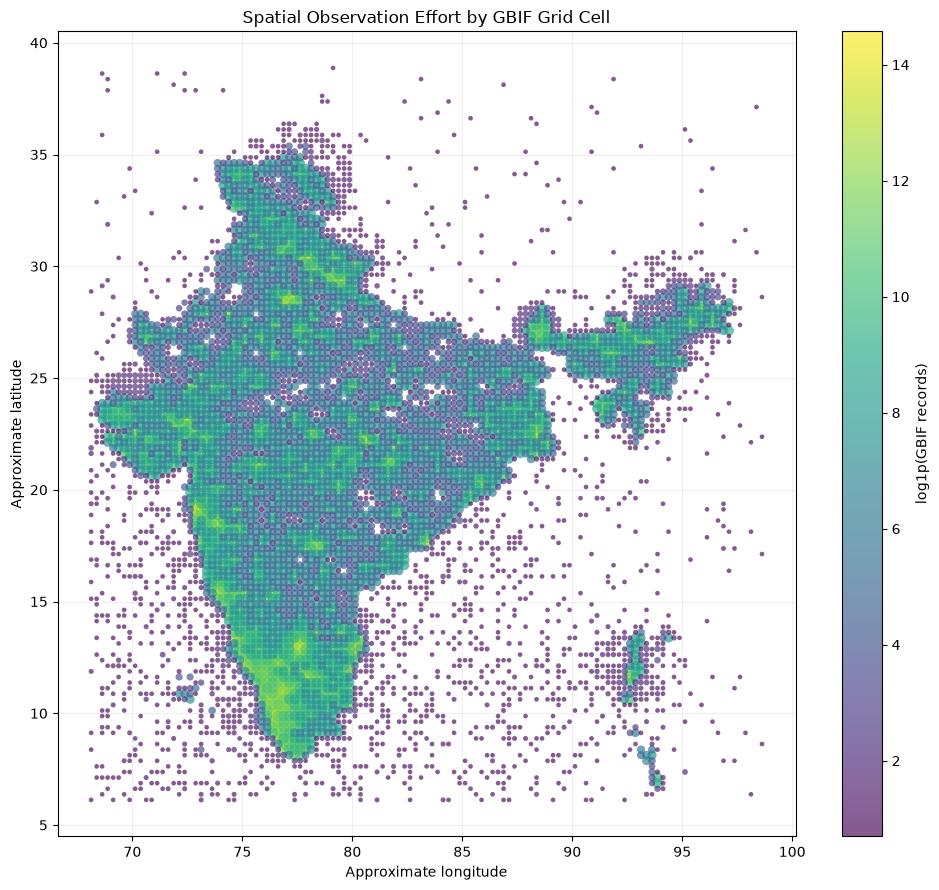

In [32]:
plot_df = spatial.dropna(subset=["longitude", "latitude"]).copy()

fig, ax = plt.subplots(figsize=(10, 9))
sizes = 8 + 70 * (
    np.log1p(plot_df["total_occurrences"])
    / np.log1p(plot_df["total_occurrences"].max())
)
scatter = ax.scatter(
    plot_df["longitude"],
    plot_df["latitude"],
    s=sizes,
    c=np.log1p(plot_df["total_occurrences"]),
    alpha=0.65,
    linewidths=0,
)
ax.set_title("Spatial Observation Effort by GBIF Grid Cell")
ax.set_xlabel("Approximate longitude")
ax.set_ylabel("Approximate latitude")
ax.grid(alpha=0.2)
fig.colorbar(scatter, ax=ax, label="log1p(GBIF records)")
plt.tight_layout()
plt.show()


## 6. Grid-level sampling coverage

Coverage is kept as separate components instead of collapsing everything into a single arbitrary score.

- `total_occurrences`: observation effort
- `distinct_species_2015_2024`: observed taxonomic coverage
- `observed_years`: temporal representation
- `usable_years`: years meeting the agreed minimum sampling threshold

In [33]:
spatial["temporal_coverage_pct"] = (
    spatial["observed_years"]
    / (ANALYSIS_END_YEAR - ANALYSIS_START_YEAR + 1)
    * 100
)

spatial["usable_year_coverage_pct"] = (
    spatial["usable_years"]
    / (ANALYSIS_END_YEAR - ANALYSIS_START_YEAR + 1)
    * 100
)

spatial["coverage_flag"] = np.select(
    [
        (spatial["usable_years"] >= MIN_BASELINE_YEARS)
        & (spatial["observed_years"] >= MIN_BASELINE_YEARS),
        spatial["observed_years"] >= 1,
    ],
    [
        "baseline_supported",
        "data_limited",
    ],
    default="data_limited",
)

coverage_summary = (
    spatial["coverage_flag"]
    .value_counts()
    .rename_axis("coverage_flag")
    .reset_index(name="grid_cells")
)

coverage_summary["percentage"] = (
    coverage_summary["grid_cells"]
    / len(spatial)
    * 100
)

coverage_summary


,coverage_flag,grid_cells,percentage
0,data_limited,3458,52.196226
1,baseline_supported,3167,47.803774


## 7. Historical baseline construction

The baseline is constructed **per grid cell**, not nationally.

For each grid cell, only Grid × Year units meeting the minimum sampling threshold are used. The baseline is the **median observed species richness** across eligible historical years, accompanied by IQR and the number of supporting years.

This is an observation-based baseline; it is not an ecological ground-truth estimate of carrying capacity or population abundance.

In [34]:
## Historical baseline per Grid × Year
##
## For each target year, only PRIOR adequately sampled years are used.
## The target year is never included in its own baseline.

baseline_source = data[
    data["sampling_adequate"]
].copy()

historical_baseline_rows = []

# Process one grid cell at a time so the historical search stays small.
for cell, group in baseline_source.groupby("eqdcellcode", sort=False):

    group = group.sort_values("year").reset_index(drop=True)

    years = group["year"].to_numpy()
    richness = group["species_richness"].to_numpy()
    occurrences = group["total_occurrences"].to_numpy()

    # Target years are taken from all observations for this grid cell,
    # including years that may not themselves be sampling-adequate.
    target_years = (
        data.loc[
            data["eqdcellcode"] == cell,
            "year"
        ]
        .drop_duplicates()
        .sort_values()
        .to_numpy()
    )

    for target_year in target_years:

        # Only adequately sampled years BEFORE the target year.
        mask = years < target_year

        if mask.sum() < MIN_BASELINE_YEARS:
            continue

        historical_richness = richness[mask]
        historical_occurrences = occurrences[mask]
        historical_years = years[mask]

        if len(np.unique(historical_years)) < MIN_BASELINE_YEARS:
            continue

        q1 = np.quantile(historical_richness, 0.25)
        q3 = np.quantile(historical_richness, 0.75)

        historical_baseline_rows.append({
            "eqdcellcode": cell,
            "target_year": int(target_year),
            "baseline_years": len(np.unique(historical_years)),
            "baseline_start_year": int(historical_years.min()),
            "baseline_end_year": int(historical_years.max()),
            "baseline_richness_median": float(np.median(historical_richness)),
            "baseline_richness_mean": float(np.mean(historical_richness)),
            "baseline_richness_q1": float(q1),
            "baseline_richness_q3": float(q3),
            "baseline_occurrence_median": float(
                np.median(historical_occurrences)
            ),
        })

historical_baseline = pd.DataFrame(historical_baseline_rows)

if historical_baseline.empty:
    raise ValueError(
        "No Grid × Year historical baselines could be constructed."
    )

historical_baseline["baseline_iqr"] = (
    historical_baseline["baseline_richness_q3"]
    - historical_baseline["baseline_richness_q1"]
)

historical_baseline["baseline_supported"] = (
    historical_baseline["baseline_years"]
    >= MIN_BASELINE_YEARS
)

print(
    "Historical Grid × Year baselines:",
    f"{len(historical_baseline):,}"
)

print(
    "Target years with supported baselines:",
    sorted(historical_baseline["target_year"].unique())
)

Historical Grid × Year baselines: 13,887
Target years with supported baselines: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [35]:
grid_year_spatiotemporal = data.merge(
    historical_baseline,
    left_on=["eqdcellcode", "year"],
    right_on=["eqdcellcode", "target_year"],
    how="left",
    validate="one_to_one",
)

grid_year_spatiotemporal["richness_deviation_from_baseline"] = (
    grid_year_spatiotemporal["species_richness"]
    - grid_year_spatiotemporal["baseline_richness_median"]
)

grid_year_spatiotemporal["baseline_relative_change_pct"] = np.where(
    grid_year_spatiotemporal["baseline_richness_median"].gt(0),
    (
        grid_year_spatiotemporal["richness_deviation_from_baseline"]
        / grid_year_spatiotemporal["baseline_richness_median"]
        * 100
    ),
    np.nan,
)

# Explicitly define the two states we need.
has_baseline = (
    grid_year_spatiotemporal["baseline_supported"]
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

is_data_limited = (
    ~grid_year_spatiotemporal["sampling_adequate"]
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

grid_year_spatiotemporal["baseline_flag"] = np.select(
    [
        is_data_limited,
        ~has_baseline,
    ],
    [
        "data_limited_current_year",
        "insufficient_historical_support",
    ],
    default="baseline_supported",
)

grid_year_spatiotemporal[
    [
        "eqdcellcode",
        "year",
        "species_richness",
        "total_occurrences",
        "baseline_start_year",
        "baseline_end_year",
        "baseline_years",
        "baseline_richness_median",
        "baseline_iqr",
        "richness_deviation_from_baseline",
        "baseline_relative_change_pct",
        "baseline_flag",
    ]
].head(20)

,eqdcellcode,year,species_richness,total_occurrences,baseline_start_year,baseline_end_year,baseline_years,baseline_richness_median,baseline_iqr,richness_deviation_from_baseline,baseline_relative_change_pct,baseline_flag
0,E083N19DB,2023,13,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data_limited_current_year
1,E083N19DB,2024,119,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_historical_support
2,E085N20DA,2015,82,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_historical_support
3,E085N20DA,2016,102,248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_historical_support
4,E085N20DA,2017,174,1875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,insufficient_historical_support
5,E085N20DA,2018,194,3273,2015.0,2017.0,3.0,102.0,46.00,92.0,90.196078,baseline_supported
6,E085N20DA,2019,144,612,2015.0,2018.0,4.0,138.0,82.00,6.0,4.347826,baseline_supported
7,E085N20DA,2020,175,1006,2015.0,2019.0,5.0,144.0,72.00,31.0,21.527778,baseline_supported
8,E085N20DA,2021,220,1661,2015.0,2020.0,6.0,159.0,62.25,61.0,38.364780,baseline_supported
9,E085N20DA,2022,141,1283,2015.0,2021.0,7.0,174.0,61.50,-33.0,-18.965517,baseline_supported


## 8. Baseline diagnostics

Large deviations are not automatically treated as biodiversity loss or recovery. The baseline output is designed as an input to the later anomaly-detection and priority-scoring stage, where coverage and persistence will also be considered.

In [36]:
supported = grid_year_spatiotemporal[
    grid_year_spatiotemporal["baseline_supported"].fillna(False)
    & grid_year_spatiotemporal["sampling_adequate"]
].copy()

print(
    "Historical-baseline-supported Grid × Year units:",
    f"{len(supported):,}"
)

print(
    "Grid cells with supported baselines:",
    f"{supported['eqdcellcode'].nunique():,}"
)

print("\nSupported target years:")
print(sorted(supported["year"].unique()))

print("\nAbsolute richness deviation statistics:")
print(
    supported["richness_deviation_from_baseline"]
    .abs()
    .describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

recent = supported[supported["year"] == ANALYSIS_END_YEAR].copy()

print(
    f"\nSupported {ANALYSIS_END_YEAR} Grid × Year units:",
    len(recent)
)

display(
    recent.sort_values(
        "richness_deviation_from_baseline"
    ).head(10)[
        [
            "eqdcellcode",
            "year",
            "species_richness",
            "total_occurrences",
            "baseline_start_year",
            "baseline_end_year",
            "baseline_years",
            "baseline_richness_median",
            "richness_deviation_from_baseline",
            "baseline_relative_change_pct",
        ]
    ]
)

Historical-baseline-supported Grid × Year units: 12,913
Grid cells with supported baselines: 2,773

Supported target years:
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Absolute richness deviation statistics:
count    12913.000000
mean        44.645706
std         46.316799
min          0.000000
50%         33.000000
75%         60.000000
90%         95.000000
95%        121.500000
99%        202.000000
max        900.000000
Name: richness_deviation_from_baseline, dtype: float64

Supported 2024 Grid × Year units: 2630


,eqdcellcode,year,species_richness,total_occurrences,baseline_start_year,baseline_end_year,baseline_years,baseline_richness_median,richness_deviation_from_baseline,baseline_relative_change_pct
22852,E087N22AA,2024,45,57,2017.0,2023.0,7.0,166.0,-121.0,-72.891566
2142,E092N24CB,2024,490,10670,2015.0,2023.0,9.0,602.0,-112.0,-18.604651
18087,E078N16DB,2024,63,189,2015.0,2023.0,9.0,163.0,-100.0,-61.349693
16758,E080N16AD,2024,80,380,2017.0,2023.0,6.0,174.0,-94.0,-54.022989
8852,E073N19AA,2024,68,160,2016.0,2023.0,6.0,155.5,-87.5,-56.270096
16932,E076N29DC,2024,49,51,2016.0,2023.0,8.0,132.0,-83.0,-62.878788
21155,E081N22DB,2024,46,58,2017.0,2023.0,7.0,128.0,-82.0,-64.062500
17688,E075N30AB,2024,14,25,2020.0,2023.0,4.0,93.0,-79.0,-84.946237
23888,E076N28AD,2024,30,32,2015.0,2023.0,7.0,108.0,-78.0,-72.222222
27975,E076N29DB,2024,44,208,2016.0,2022.0,5.0,121.0,-77.0,-63.636364


## 9. Export Person 2 analytical outputs

In [37]:
## Export finalized Person 2 analytical outputs

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_paths = {
    "spatial_coverage": OUTPUT_DIR / "spatial_temporal_grid_coverage.csv",
    "historical_baseline": OUTPUT_DIR / "spatial_temporal_grid_baseline.csv",
    "grid_year_spatiotemporal": (
        OUTPUT_DIR / "grid_year_spatial_temporal_intelligence.parquet"
    ),
    "temporal_summary": OUTPUT_DIR / "spatial_temporal_annual_summary.csv",
    "sampling_summary": OUTPUT_DIR / "spatial_temporal_sampling_summary.csv",
}

# Spatial coverage
spatial.to_csv(
    output_paths["spatial_coverage"],
    index=False
)

# IMPORTANT: export the new historical baseline
historical_baseline.to_csv(
    output_paths["historical_baseline"],
    index=False
)

# Export Grid × Year data with the historical baseline attached
grid_year_spatiotemporal.to_parquet(
    output_paths["grid_year_spatiotemporal"],
    index=False
)

# Temporal summary
annual.to_csv(
    output_paths["temporal_summary"],
    index=False
)

# Sampling / baseline summary
sampling_summary = pd.DataFrame({
    "metric": [
        "spatial_observation_effort_gini",
        "spatial_top10_grid_record_share_pct",
        "temporal_observation_effort_gini_2015_2024",
        "total_grid_cells",
        "grid_cells_with_supported_baseline",
        "historical_baseline_grid_year_units",
        "grid_year_units",
        "grid_year_units_sampling_adequate",
        "supported_2024_grid_year_units",
    ],
    "value": [
        spatial_gini,
        spatial_top10_share * 100,
        temporal_gini,
        len(spatial),
        int(
            historical_baseline["baseline_supported"].sum()
        ),
        len(historical_baseline),
        len(data),
        int(data["sampling_adequate"].sum()),
        len(
            grid_year_spatiotemporal[
                (grid_year_spatiotemporal["year"] == ANALYSIS_END_YEAR)
                & grid_year_spatiotemporal["baseline_supported"].fillna(False)
                & grid_year_spatiotemporal["sampling_adequate"]
            ]
        ),
    ],
})

sampling_summary.to_csv(
    output_paths["sampling_summary"],
    index=False
)

print("Created finalized Person 2 outputs:")

for name, path in output_paths.items():
    print(f"- {name}: {path.relative_to(PROJECT_ROOT)}")

Created finalized Person 2 outputs:
- spatial_coverage: data\processed\analytics\spatial_temporal_grid_coverage.csv
- historical_baseline: data\processed\analytics\spatial_temporal_grid_baseline.csv
- grid_year_spatiotemporal: data\processed\analytics\grid_year_spatial_temporal_intelligence.parquet
- temporal_summary: data\processed\analytics\spatial_temporal_annual_summary.csv
- sampling_summary: data\processed\analytics\spatial_temporal_sampling_summary.csv


In [38]:
import pyarrow.parquet as pq
pf_final = pq.ParquetFile(
    output_paths["grid_year_spatiotemporal"]
)

print("Rows:", pf_final.metadata.num_rows)
print("Columns:", pf_final.metadata.num_columns)
print("Schema:")
print(pf_final.schema)

Rows: 36078
Columns: 23
Schema:
required group field_id=-1 schema {
  optional binary field_id=-1 eqdcellcode (String);
  optional int64 field_id=-1 year;
  optional int64 field_id=-1 total_occurrences;
  optional int64 field_id=-1 species_richness;
  optional double field_id=-1 shannon_diversity;
  optional double field_id=-1 simpson_diversity;
  optional double field_id=-1 pielou_evenness;
  optional boolean field_id=-1 sampling_adequate;
  optional binary field_id=-1 sampling_flag (String);
  optional double field_id=-1 target_year;
  optional double field_id=-1 baseline_years;
  optional double field_id=-1 baseline_start_year;
  optional double field_id=-1 baseline_end_year;
  optional double field_id=-1 baseline_richness_median;
  optional double field_id=-1 baseline_richness_mean;
  optional double field_id=-1 baseline_richness_q1;
  optional double field_id=-1 baseline_richness_q3;
  optional double field_id=-1 baseline_occurrence_median;
  optional double field_id=-1 baseline_i

In [39]:
print(
    "Final columns:",
    pf_final.schema.names
)

Final columns: ['eqdcellcode', 'year', 'total_occurrences', 'species_richness', 'shannon_diversity', 'simpson_diversity', 'pielou_evenness', 'sampling_adequate', 'sampling_flag', 'target_year', 'baseline_years', 'baseline_start_year', 'baseline_end_year', 'baseline_richness_median', 'baseline_richness_mean', 'baseline_richness_q1', 'baseline_richness_q3', 'baseline_occurrence_median', 'baseline_iqr', 'baseline_supported', 'richness_deviation_from_baseline', 'baseline_relative_change_pct', 'baseline_flag']


## 10. Interpretation checkpoint

1. Spatial sampling concentration is computed from **observation effort**, not species richness.
2. Temporal trends show observation effort and observed richness separately.
3. Low-coverage Grid × Year units are flagged rather than interpreted as low biodiversity.
4. Grid-level baselines require repeated adequately sampled years.
5. Baseline deviations are **not ecological diagnoses**; they are inputs for the later anomaly-detection stage.
6. The next stage should combine anomaly magnitude, persistence, sampling coverage, and indicator changes before assigning a priority score.

In [40]:
print("===== PERSON 2 SPATIAL-TEMPORAL INTELLIGENCE COMPLETE =====")
print(f"Analysis period: {ANALYSIS_START_YEAR}-{ANALYSIS_END_YEAR}")
print(f"Grid cells: {len(spatial):,}")
print(f"Grid × Year units: {len(data):,}")
print(f"Spatial observation-effort Gini: {spatial_gini:.4f}")
print(f"Grid cells with supported baseline: {int(baseline['baseline_supported'].sum()):,}")


===== PERSON 2 SPATIAL-TEMPORAL INTELLIGENCE COMPLETE =====
Analysis period: 2015-2024
Grid cells: 6,625
Grid × Year units: 36,078
Spatial observation-effort Gini: 0.9213


NameError: name 'baseline' is not defined